# Global Rabi

Here we simulate a global rabi, subspace rabi and two-level rabi oscillation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from psyduck.operations import parity_operator
from psyduck import Spin

## global rabi

In [2]:
nucleus = Spin(I=7/2)
d_angle = np.pi/100
angles = np.arange(0, 2*np.pi + d_angle, d_angle)
states = np.zeros((len(angles), nucleus.dim), dtype=complex)
Iz_exp = np.zeros((len(angles)))
for i, angle in enumerate(angles):
    nucleus.global_rotate(d_angle, axis='x')
    states[i] = nucleus.state.full().flatten()
    Iz_exp[i] = nucleus.Iz()

Text(0, 0.5, '<$I_z$>')

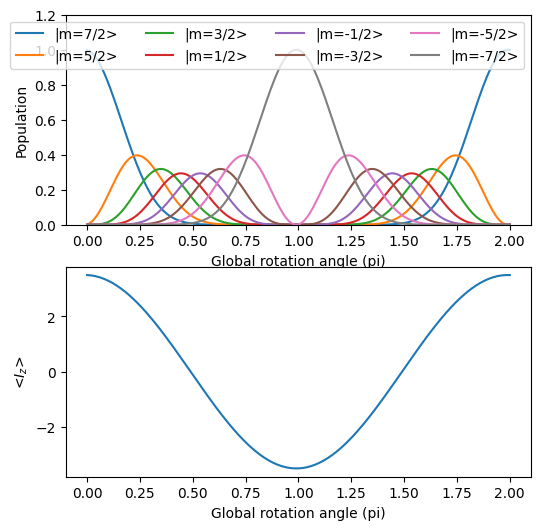

In [3]:
fig, ax = plt.subplots(2,1, figsize=(6,6))
ax[0].plot(angles/np.pi, np.abs(states)**2)
ax[0].legend([f'|m={m}/2>' for m in range(int(nucleus.I*2), int(-nucleus.I*2 - 1), -2)], ncols=4, loc='upper right')
ax[0].set_ylim([0, 1.2])

ax[1].plot(angles/np.pi, Iz_exp)
ax[1].set_ylim([-7/2-0.3, 7/2+0.3])

ax[0].set_xlabel('Global rotation angle (pi)')
ax[1].set_xlabel('Global rotation angle (pi)')
ax[0].set_ylabel('Population')
ax[1].set_ylabel('<$I_z$>')

## subspace global rotation

In [20]:
positive_subspace = [7/2, 5/2, 3/2, 1/2]

nucleus = Spin(I=7/2)
d_angle = np.pi/100
angles = np.arange(0, 2*np.pi + d_angle, d_angle)
states = np.zeros((len(angles), nucleus.dim), dtype=complex)
Iz_exp = np.zeros((len(angles)))
for i, angle in enumerate(angles):
    nucleus.subspace_rotate(d_angle, axis='x', levels=positive_subspace)
    states[i] = nucleus.state.full().flatten()
    Iz_exp[i] = nucleus.Iz()

Text(0, 0.5, '<$I_z$>')

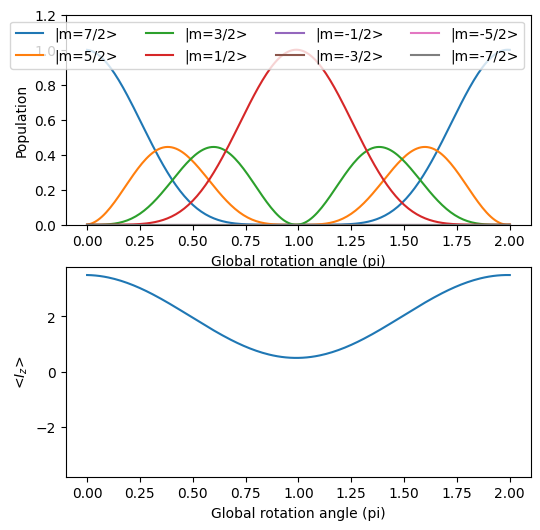

In [21]:
fig, ax = plt.subplots(2,1, figsize=(6,6))
ax[0].plot(angles/np.pi, np.abs(states)**2)
ax[0].legend([f'|m={m}/2>' for m in range(int(nucleus.I*2), int(-nucleus.I*2 - 1), -2)], ncols=4, loc='upper right')
ax[0].set_ylim([0, 1.2])

ax[1].plot(angles/np.pi, Iz_exp)
ax[1].set_ylim([-7/2-0.3, 7/2+0.3])

ax[0].set_xlabel('Global rotation angle (pi)')
ax[1].set_xlabel('Global rotation angle (pi)')
ax[0].set_ylabel('Population')
ax[1].set_ylabel('<$I_z$>')

In [8]:
from psyduck.operations import subspace_rotation

In [12]:
subspace_rotation(7/2, np.pi/2, 'x', levels=(7/2, 5/2, 3/2))

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 0.5+0.j          0. -0.70710678j -0.5+0.j          0. +0.j
   0. +0.j          0. +0.j          0. +0.j          0. +0.j        ]
 [ 0. -0.70710678j  0. +0.j          0. -0.70710678j  0. +0.j
   0. +0.j          0. +0.j          0. +0.j          0. +0.j        ]
 [-0.5+0.j          0. -0.70710678j  0.5+0.j          0. +0.j
   0. +0.j          0. +0.j          0. +0.j          0. +0.j        ]
 [ 0. +0.j          0. +0.j          0. +0.j          1. +0.j
   0. +0.j          0. +0.j          0. +0.j          0. +0.j        ]
 [ 0. +0.j          0. +0.j          0. +0.j          0. +0.j
   1. +0.j          0. +0.j          0. +0.j          0. +0.j        ]
 [ 0. +0.j          0. +0.j          0. +0.j          0. +0.j
   0. +0.j          1. +0.j          0. +0.j          0. +0.j        ]
 [ 0. +0.j          0. +0.j          0. +0.j          0. +0.j
   0. +0.j          0. +0.j          1. +0